# Preprocessing Data Science Job Posting Folder

## Alur (Belum Fix)
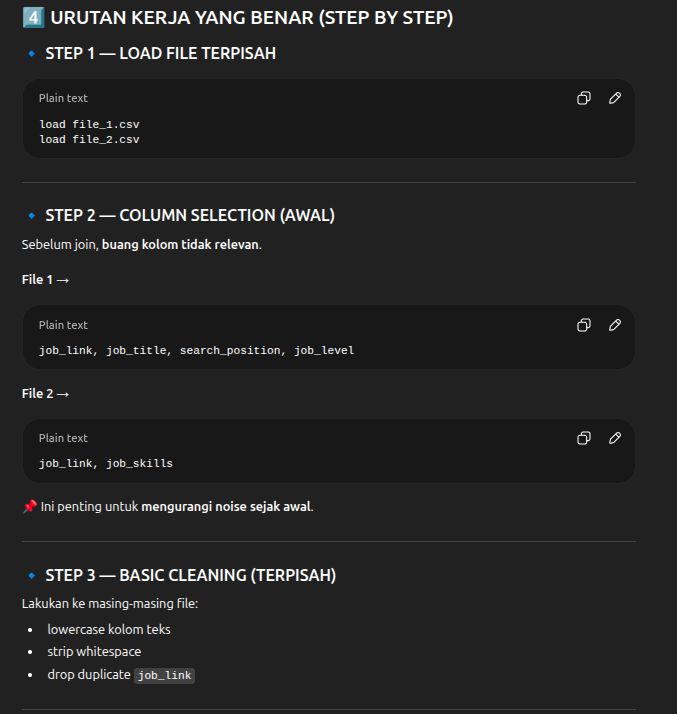
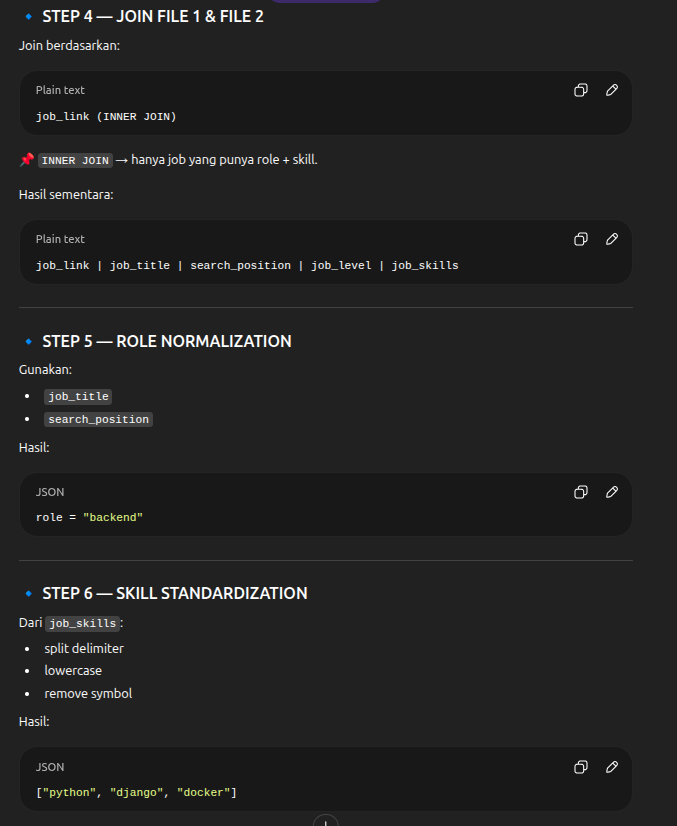
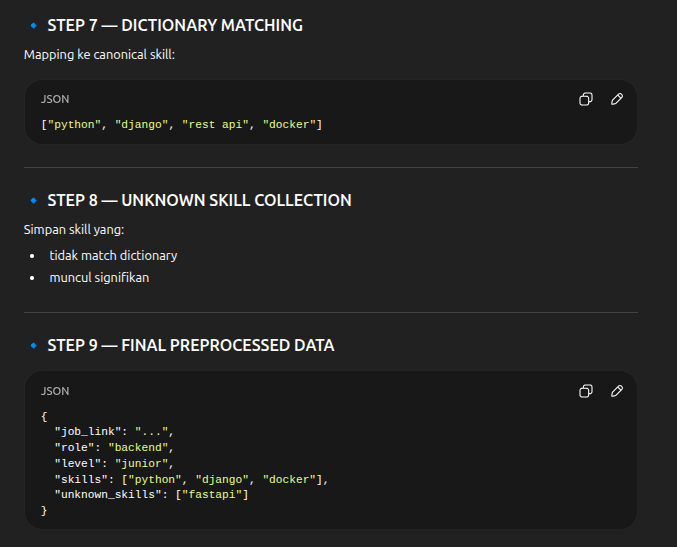
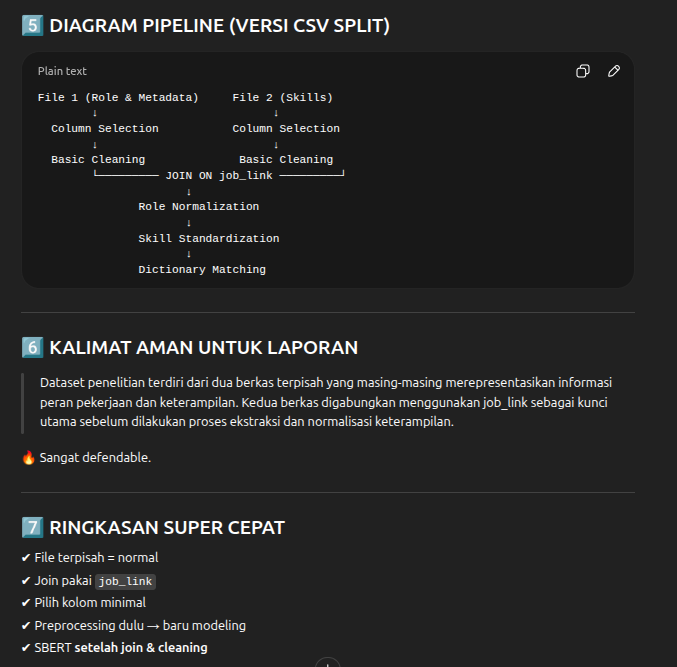

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## File job_postings

In [15]:
id_jp = '1p481647dpU6EraGDw0zCnfH-2F3OReEC'
url_jp = f'https://drive.google.com/uc?id={id_jp}'
df_jp = pd.read_csv(url_jp)
df_jp.head()

,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite


In [16]:
df_jp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12217 entries, 0 to 12216
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_link             12217 non-null  object
 1   last_processed_time  12217 non-null  object
 2   last_status          12217 non-null  object
 3   got_summary          12217 non-null  object
 4   got_ner              12217 non-null  object
 5   is_being_worked      12217 non-null  object
 6   job_title            12217 non-null  object
 7   company              12217 non-null  object
 8   job_location         12216 non-null  object
 9   first_seen           12217 non-null  object
 10  search_city          12217 non-null  object
 11  search_country       12217 non-null  object
 12  search_position      12217 non-null  object
 13  job_level            12217 non-null  object
 14  job_type             12217 non-null  object
dtypes: object(15)
memory usage: 1.4+ MB


In [17]:
df_jp.columns

Index(['job_link', 'last_processed_time', 'last_status', 'got_summary',
       'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location',
       'first_seen', 'search_city', 'search_country', 'search_position',
       'job_level', 'job_type'],
      dtype='object')

In [18]:
# Drop kolom
df_jp.drop(columns=['last_processed_time', 'last_status', 'got_summary',
       'got_ner', 'is_being_worked', 'company', 'job_location',
       'first_seen', 'search_city', 'search_country', 'job_type'], inplace=True)

df_jp

,job_link,job_title,search_position,job_level
0,https://www.linkedin.com/jobs/view/senior-mach...,Senior Machine Learning Engineer,Agricultural-Research Engineer,Mid senior
1,https://www.linkedin.com/jobs/view/principal-s...,"Principal Software Engineer, ML Accelerators",Set-Key Driver,Mid senior
2,https://www.linkedin.com/jobs/view/senior-etl-...,Senior ETL Data Warehouse Specialist,Technical Support Specialist,Associate
3,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Warehouse Developer / Architect,Architect,Mid senior
4,https://www.linkedin.com/jobs/view/lead-data-e...,Lead Data Engineer,Maintenance Data Analyst,Mid senior
...,...,...,...,...
12212,https://uk.linkedin.com/jobs/view/data-reporti...,"Data Reporting Manager, FOOTBALL ASSOCIATION",Manager Forms Analysis,Mid senior
12213,https://www.linkedin.com/jobs/view/corporate-a...,Corporate AML Alert Investigation Specialist,Teller,Mid senior
12214,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Scientist,Mathematician,Mid senior
12215,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Engineer,Protection Engineer,Mid senior


In [19]:
# drop duplicate `job_link`
df_jp.drop_duplicates(subset='job_link', inplace=True)
df_jp.dropna(inplace=True)

In [20]:
#strip whitespace + lowercase
import re

def casefolding(text):
    return text.lower()

def cleaning(text):
    text = re.sub(r"http\S+", "", text)
    
    text = text.replace('\n', ' ')
    text = text.replace('*','')
    
    text = text.strip()
    
    text = re.sub(r'\s+', ' ', text)
    
    return text

for col in df_jp.columns:
    if col == 'job_link':
        pass
    else:
        df_jp.loc[:, f"clean_{col}"] = df_jp[col].apply(casefolding)
        df_jp.loc[:, f"clean_{col}"] = df_jp[f"clean_{col}"].apply(cleaning)
df_jp

,job_link,job_title,search_position,job_level,clean_job_title,clean_search_position,clean_job_level
0,https://www.linkedin.com/jobs/view/senior-mach...,Senior Machine Learning Engineer,Agricultural-Research Engineer,Mid senior,senior machine learning engineer,agricultural-research engineer,mid senior
1,https://www.linkedin.com/jobs/view/principal-s...,"Principal Software Engineer, ML Accelerators",Set-Key Driver,Mid senior,"principal software engineer, ml accelerators",set-key driver,mid senior
2,https://www.linkedin.com/jobs/view/senior-etl-...,Senior ETL Data Warehouse Specialist,Technical Support Specialist,Associate,senior etl data warehouse specialist,technical support specialist,associate
3,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Warehouse Developer / Architect,Architect,Mid senior,senior data warehouse developer / architect,architect,mid senior
4,https://www.linkedin.com/jobs/view/lead-data-e...,Lead Data Engineer,Maintenance Data Analyst,Mid senior,lead data engineer,maintenance data analyst,mid senior
...,...,...,...,...,...,...,...
12212,https://uk.linkedin.com/jobs/view/data-reporti...,"Data Reporting Manager, FOOTBALL ASSOCIATION",Manager Forms Analysis,Mid senior,"data reporting manager, football association",manager forms analysis,mid senior
12213,https://www.linkedin.com/jobs/view/corporate-a...,Corporate AML Alert Investigation Specialist,Teller,Mid senior,corporate aml alert investigation specialist,teller,mid senior
12214,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Scientist,Mathematician,Mid senior,senior data scientist,mathematician,mid senior
12215,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Engineer,Protection Engineer,Mid senior,senior data engineer,protection engineer,mid senior


## File job_skills

In [26]:
id_js = '1v57BXUB_JQF0b3YwrkcJeRL6bDRXbQpC'
url_js = f'https://drive.google.com/uc?id={id_js}'
df_js = pd.read_csv(url_js)
df_js.head()

,job_link,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,"ETL, Data Integration, Data Transformation, Da..."
3,https://www.linkedin.com/jobs/view/senior-data...,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [27]:
df_js.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12217 entries, 0 to 12216
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   job_link    12217 non-null  object
 1   job_skills  12212 non-null  object
dtypes: object(2)
memory usage: 191.0+ KB


In [28]:
df_js.columns

Index(['job_link', 'job_skills'], dtype='object')

In [29]:
# drop duplicate `job_link`
df_js.drop_duplicates(subset='job_link', inplace=True)
df_js.dropna(inplace=True)

In [30]:
#strip whitespace + lowercase
import re

def casefolding(text):
    return text.lower()

def cleaning(text):
    text = re.sub(r"http\S+", "", text)
    
    text = text.replace('\n', ' ')
    text = text.replace('*','')
    
    text = text.strip()
    
    text = re.sub(r'\s+', ' ', text)
    
    return text

df_js['clean_job_skills'] = df_js['job_skills'].apply(casefolding)
df_js['clean_job_skills'] = df_js['clean_job_skills'].apply(cleaning)
df_js

,job_link,job_skills,clean_job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ...","machine learning, programming, python, scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,...","c++, python, pytorch, tensorflow, mxnet, cuda,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,"ETL, Data Integration, Data Transformation, Da...","etl, data integration, data transformation, da..."
3,https://www.linkedin.com/jobs/view/senior-data...,"Data Lakes, Data Bricks, Azure Data Factory Pi...","data lakes, data bricks, azure data factory pi..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S...","java, scala, python, rdbms, nosql, redshift, s..."
...,...,...,...
12212,https://uk.linkedin.com/jobs/view/data-reporti...,"Dashboard development, Reporting, Power BI, SQ...","dashboard development, reporting, power bi, sq..."
12213,https://www.linkedin.com/jobs/view/corporate-a...,"Investigation, Antimoney laundering, Fraud, Ba...","investigation, antimoney laundering, fraud, ba..."
12214,https://www.linkedin.com/jobs/view/senior-data...,"Data Science, Quantitative Modeling, SQL, Data...","data science, quantitative modeling, sql, data..."
12215,https://www.linkedin.com/jobs/view/senior-data...,"Data Engineering, Data Quality, SQL, Python, T...","data engineering, data quality, sql, python, t..."


## Join File

In [31]:
# job_link (INNER JOIN)
df = pd.merge(df_jp, df_js, on='job_link', how='inner')
df

,job_link,job_title,search_position,job_level,clean_job_title,clean_search_position,clean_job_level,job_skills,clean_job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,Senior Machine Learning Engineer,Agricultural-Research Engineer,Mid senior,senior machine learning engineer,agricultural-research engineer,mid senior,"Machine Learning, Programming, Python, Scala, ...","machine learning, programming, python, scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"Principal Software Engineer, ML Accelerators",Set-Key Driver,Mid senior,"principal software engineer, ml accelerators",set-key driver,mid senior,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,...","c++, python, pytorch, tensorflow, mxnet, cuda,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,Senior ETL Data Warehouse Specialist,Technical Support Specialist,Associate,senior etl data warehouse specialist,technical support specialist,associate,"ETL, Data Integration, Data Transformation, Da...","etl, data integration, data transformation, da..."
3,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Warehouse Developer / Architect,Architect,Mid senior,senior data warehouse developer / architect,architect,mid senior,"Data Lakes, Data Bricks, Azure Data Factory Pi...","data lakes, data bricks, azure data factory pi..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,Lead Data Engineer,Maintenance Data Analyst,Mid senior,lead data engineer,maintenance data analyst,mid senior,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S...","java, scala, python, rdbms, nosql, redshift, s..."
...,...,...,...,...,...,...,...,...,...
12207,https://uk.linkedin.com/jobs/view/data-reporti...,"Data Reporting Manager, FOOTBALL ASSOCIATION",Manager Forms Analysis,Mid senior,"data reporting manager, football association",manager forms analysis,mid senior,"Dashboard development, Reporting, Power BI, SQ...","dashboard development, reporting, power bi, sq..."
12208,https://www.linkedin.com/jobs/view/corporate-a...,Corporate AML Alert Investigation Specialist,Teller,Mid senior,corporate aml alert investigation specialist,teller,mid senior,"Investigation, Antimoney laundering, Fraud, Ba...","investigation, antimoney laundering, fraud, ba..."
12209,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Scientist,Mathematician,Mid senior,senior data scientist,mathematician,mid senior,"Data Science, Quantitative Modeling, SQL, Data...","data science, quantitative modeling, sql, data..."
12210,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Engineer,Protection Engineer,Mid senior,senior data engineer,protection engineer,mid senior,"Data Engineering, Data Quality, SQL, Python, T...","data engineering, data quality, sql, python, t..."


In [32]:
# Proses data null + duplicate
# Role Normalization

def map_role(title):
    title = title.lower()
    
    if 'data analyst' in title:
        return 'data analyst'
    elif 'frontend' in title or 'front end' in title or 'react' in title:
        return 'frontend'
    elif "backend" in title or 'back end' in title or "node" in title:
        return "backend"
    else:
        return None
df['role'] = df['job_title'].apply(map_role)
df = df[df['role'].notnull()]
df


,job_link,job_title,search_position,job_level,clean_job_title,clean_search_position,clean_job_level,job_skills,clean_job_skills,role
8,https://www.linkedin.com/jobs/view/senior-fina...,Senior Financial Data Analyst,Budget Officer,Mid senior,senior financial data analyst,budget officer,mid senior,"Problem solving, Data analysis, Predictive ana...","problem solving, data analysis, predictive ana...",data analyst
10,https://www.linkedin.com/jobs/view/sr-workforc...,Sr. Workforce Management Data Analyst,Management Analyst,Mid senior,sr. workforce management data analyst,management analyst,mid senior,"SQL, Database Administration, Advanced Statist...","sql, database administration, advanced statist...",data analyst
16,https://ca.linkedin.com/jobs/view/data-analyst...,Data Analyst Part Time,Data Entry Clerk,Mid senior,data analyst part time,data entry clerk,mid senior,"Data Analysis, Data Visualization, Statistical...","data analysis, data visualization, statistical...",data analyst
20,https://www.linkedin.com/jobs/view/contractor-...,Contractor - Epic Clarity Data Analyst - Reven...,Data Entry Clerk,Mid senior,contractor - epic clarity data analyst - reven...,data entry clerk,mid senior,"Revenue Cycle, Healthcare Data Analysis, Data ...","revenue cycle, healthcare data analysis, data ...",data analyst
28,https://www.linkedin.com/jobs/view/vcp-design-...,VCP Design to Value Project Manager and Data A...,Data Entry Clerk,Mid senior,vcp design to value project manager and data a...,data entry clerk,mid senior,"Variable Cost Productivity, Data Analytics, Co...","variable cost productivity, data analytics, co...",data analyst
...,...,...,...,...,...,...,...,...,...,...
12100,https://www.linkedin.com/jobs/view/sc-master-d...,SC Master Data Analyst,Data Entry Clerk,Mid senior,sc master data analyst,data entry clerk,mid senior,"SAP, Parameters, MPS, MRP, Supply Chain Flow, ...","sap, parameters, mps, mrp, supply chain flow, ...",data analyst
12127,https://www.linkedin.com/jobs/view/contractor-...,Contractor - Epic Clarity Data Analyst - Reven...,Actuary,Mid senior,contractor - epic clarity data analyst - reven...,actuary,mid senior,"Revenue Cycle, Healthcare Data, Data Analysis,...","revenue cycle, healthcare data, data analysis,...",data analyst
12134,https://uk.linkedin.com/jobs/view/senior-backe...,Senior Backend and Cloud Engineer - Machine Le...,Computer Programmer,Mid senior,senior backend and cloud engineer - machine le...,computer programmer,mid senior,"Python, Django, Postgres, PubSub, Kubernetes, ...","python, django, postgres, pubsub, kubernetes, ...",backend
12141,https://www.linkedin.com/jobs/view/senior-data...,Senior Data Analyst,Operations-Research Analyst,Mid senior,senior data analyst,operations-research analyst,mid senior,"Data Analytics, Data Insights, Tableau, Power ...","data analytics, data insights, tableau, power ...",data analyst


In [33]:
df['role'].value_counts()

role
data analyst    1888
backend           19
frontend           5
Name: count, dtype: int64